In [1]:
import numpy as np
from mayavi import mlab

def visualize_ot_mapping_3d(
    X1, X2, P,
    labels1, labels2,
    label_colors=None,
    z1=0.0, z2=1.0,
    top_k=1,
    prob_threshold=0.0,
    max_edges=800,
    edge_opacity=0.15,
    edge_color=(0.2, 0.2, 0.2),
    edge_thickness=None,
    point_size=4.0,
    bg_color=(1, 1, 1),
    figure_size=(1000, 800),
    seed=0,
    save=False,
    savename=None,
    selected_cell_types=None,
    non_selected_color=(0.85, 0.85, 0.85),
    non_selected_point_size=None,
):
    """
    Visualize OT mapping between two slices using Mayavi in 3D.

    Parameters
    ----------
    X1, X2 : array-like
        Coordinates of points in slice 1 and slice 2.
        Shape: (n1, 2) or (n1, 3), (n2, 2) or (n2, 3).
    P : array-like
        OT matrix of shape (n1, n2).
    labels1, labels2 : array-like
        Cell-type labels for X1 and X2.
    label_colors : dict or None
        Optional mapping {label: (r,g,b)} with values in [0,1].
        If None, colors are assigned automatically.
    z1, z2 : float
        z coordinates where the two slices will be placed.
    top_k : int
        For each source point in X1, keep at most top_k target connections.
    prob_threshold : float
        Ignore edges with P[i,j] < prob_threshold.
    max_edges : int
        Maximum number of edges to draw in total. If exceeded, subsample.
    edge_opacity : float
        Opacity of edges (0–1).
    edge_color : tuple
        RGB color of edges, values in [0,1].
    edge_thickness : float or None
        Tube radius for edges in plot3d. None falls back to line width.
    point_size : float
        Size of points (scale_factor for spheres) for selected cell types.
    bg_color : tuple
        Background color of the figure.
    figure_size : tuple
        Size of the Mayavi figure (width, height).
    seed : int
        Random seed for edge subsampling.
    save : bool
        If True, save a screenshot instead of showing interactively.
    savename : str or None
        Path to save the screenshot if save=True.
    selected_cell_types : list or None
        If not None, these cell types are emphasized (full color & size).
        All other cell types are shown in light gray & smaller size, and
        edges are drawn only if they touch at least one selected cell type.
    non_selected_color : tuple
        RGB color used for all non-selected cell types.
    non_selected_point_size : float or None
        Size for non-selected cell types. If None, defaults to 0.4*point_size.
    """

    X1 = np.asarray(X1)
    X2 = np.asarray(X2)
    P  = np.asarray(P)

    n1, n2 = P.shape
    assert X1.shape[0] == n1
    assert X2.shape[0] == n2

    if non_selected_point_size is None:
        non_selected_point_size = point_size * 0.4

    # Handle 2D vs 3D input
    def ensure_3d(X, z_plane):
        if X.shape[1] == 2:
            x, y = X[:, 0], X[:, 1]
            z = np.full_like(x, z_plane, dtype=float)
        elif X.shape[1] == 3:
            x, y, _ = X[:, 0], X[:, 1], X[:, 2]
            z = np.full_like(x, z_plane, dtype=float)  # flatten in z
        else:
            raise ValueError("X must have 2 or 3 columns.")
        return x, y, z

    x1, y1, z1_arr = ensure_3d(X1, z1)
    x2, y2, z2_arr = ensure_3d(X2, z2)

    # ----- Build a color map for labels -----
    labels1 = np.asarray(labels1)
    labels2 = np.asarray(labels2)
    all_labels = np.unique(np.concatenate([labels1, labels2]))

    if label_colors is None:
        rng = np.random.default_rng(42)
        label_colors = {}
        for lab in all_labels:
            color = rng.random(3) * 0.7 + 0.3  # avoid too dark
            label_colors[lab] = tuple(color)
    else:
        missing = [lab for lab in all_labels if lab not in label_colors]
        if missing:
            rng = np.random.default_rng(42)
            for lab in missing:
                color = rng.random(3) * 0.7 + 0.3
                label_colors[lab] = tuple(color)

    # Selected set
    if selected_cell_types is not None:
        selected_set = set(selected_cell_types)
    else:
        selected_set = None

    # ----- Create figure -----
    mlab.figure(bgcolor=bg_color, size=figure_size)

    # ----- Plot points for each slice, colored by label -----
    # Slice 1
    for lab in np.unique(labels1):
        mask = (labels1 == lab)
        if not np.any(mask):
            continue

        is_selected = (selected_set is None) or (lab in selected_set)
        color = label_colors[lab] if is_selected else non_selected_color
        size  = point_size        if is_selected else non_selected_point_size

        mlab.points3d(
            x1[mask], y1[mask], z1_arr[mask],
            scale_factor=size,
            color=color,
            mode="sphere",
            resolution=16,
            opacity=1.0,
        )

    # Slice 2
    for lab in np.unique(labels2):
        mask = (labels2 == lab)
        if not np.any(mask):
            continue

        is_selected = (selected_set is None) or (lab in selected_set)
        color = label_colors[lab] if is_selected else non_selected_color
        size  = point_size        if is_selected else non_selected_point_size

        mlab.points3d(
            x2[mask], y2[mask], z2_arr[mask],
            scale_factor=size,
            color=color,
            mode="sphere",
            resolution=16,
            opacity=1.0,
        )

    # ----- Select a subset of OT edges to avoid clutter -----
    edges = []

    for i in range(n1):
        row = P[i]
        if top_k >= len(row):
            top_idx = np.argsort(row)[::-1]  # descending
        else:
            top_idx = np.argpartition(row, -top_k)[-top_k:]
            top_idx = top_idx[np.argsort(row[top_idx])[::-1]]

        for j in top_idx:
            w = row[j]
            if w < prob_threshold or w <= 0:
                continue

            # Only keep edges touching selected cell types (if any selected)
            if selected_set is not None:
                if (labels1[i] not in selected_set) and (labels2[j] not in selected_set):
                    continue

            edges.append((i, j, w))

    # If still too many, subsample globally
    if len(edges) > max_edges:
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(edges), size=max_edges, replace=False)
        edges = [edges[k] for k in idx]

    # ----- Draw edges as thin semi-transparent lines -----
    for (i, j, w) in edges:
        mlab.plot3d(
            [x1[i], x2[j]],
            [y1[i], y2[j]],
            [z1_arr[i], z2_arr[j]],
            tube_radius=edge_thickness,
            tube_sides=32,
            line_width=1.0,
            color=edge_color,
            opacity=edge_opacity,
        )

    # Optional: adjust view
    mlab.orientation_axes()
    mlab.view(azimuth=60, elevation=75, distance='auto')
    mlab.axes().parent.visible = False

    if save:
        fig = mlab.gcf()
        fig.scene.anti_aliasing_frames = 16  # or fewer if too slow
        mlab.savefig(savename, size=(3000, 2400))
    else:
        mlab.show()

import numpy as np

def rigid_align_with_plan(X1, X2, P):
    """
    Compute a rigid transform (R, t) that aligns X1 to X2 given a soft
    correspondence matrix P.

    Parameters
    ----------
    X1 : (n, d) array
        Source coordinates.
    X2 : (m, d) array
        Target coordinates.
    P  : (n, m) array
        Nonnegative weights (e.g. OT plan) giving correspondence strength
        between X1[i] and X2[j].

    Returns
    -------
    R : (d, d) array
        Rotation matrix.
    t : (d,) array
        Translation vector.
    X1_aligned : (n, d) array
        Transformed X1: X1 @ R.T + t
    """

    X1 = np.asarray(X1)
    X2 = np.asarray(X2)
    P = np.asarray(P)
    n, d = X1.shape
    m, d2 = X2.shape
    assert d == d2, "X1 and X2 must have the same dimensionality."
    assert P.shape == (n, m), "P must be of shape (n, m)."

    total_mass = P.sum()
    if total_mass <= 0:
        raise ValueError("P has zero total mass; cannot compute alignment.")

    # Normalize plan to sum to 1
    W = P / total_mass

    # Weighted centroids
    row_weights = W.sum(axis=1)              # (n,)
    col_weights = W.sum(axis=0)              # (m,)

    mu1 = (X1 * row_weights[:, None]).sum(axis=0)  # (d,)
    mu2 = (X2 * col_weights[:, None]).sum(axis=0)  # (d,)

    # Centered coordinates
    X1c = X1 - mu1
    X2c = X2 - mu2

    # Weighted cross-covariance: C = X1c^T W X2c
    C = X1c.T @ W @ X2c  # (d, d)

    # SVD
    U, S, Vt = np.linalg.svd(C)
    R = Vt.T @ U.T

    # Enforce a proper rotation (determinant +1)
    # if np.linalg.det(R) < 0:
    #     Vt[-1, :] *= -1
    #     R = Vt.T @ U.T

    # Translation
    t = mu2 - R @ mu1

    # Apply transform to X1 (row-wise: x -> R x + t)
    X1_aligned = X1 @ R.T + t

    return R, t, X1_aligned


objc[13853]: Class RunLoopModeTracker is implemented in both /opt/anaconda3/envs/mayavi_env/lib/libQt5Core.5.15.15.dylib (0x114ebd370) and /opt/anaconda3/envs/mayavi_env/lib/libQt6Core.6.9.3.dylib (0x310c255d0). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[13853]: Class QT_ROOT_LEVEL_POOL__THESE_OBJECTS_WILL_BE_RELEASED_WHEN_QAPP_GOES_OUT_OF_SCOPE is implemented in both /opt/anaconda3/envs/mayavi_env/lib/libQt5Core.5.15.15.dylib (0x114ebd2f8) and /opt/anaconda3/envs/mayavi_env/lib/libQt6Core.6.9.3.dylib (0x310c25698). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[13853]: Class KeyValueObserver is implemented in both /opt/anaconda3/envs/mayavi_env/lib/libQt5Core.5.15.15.dylib (0x114ebd320) and /opt/anaconda3/envs/mayavi_env/lib/libQt6Core.6.9.3.dylib (0x310c256c0). This may cause spurious casting failures and mysterious crashes. One of the 

In [2]:
import numpy as np
import pandas as pd
import scanpy as sc
np.set_printoptions(precision=3, suppress=True)
import matplotlib.pyplot as plt

In [3]:
import os
import anndata
def load_mHypothalamus(root_dir='./mHypothalamus', section_id='0.26'):
    # section id = '0.26', '0.21', '0.16', '0.11', '0.06', '0.01', '-0.04', '-0.09', '-0.14', '-0.19', '-0.24', '-0.29' 12 in total
    # cluster =     15      15      14      15      15      15      14       15       15       15      16        15
    info_file = os.path.join(root_dir, 'MERFISH_Animal1_info.xlsx')
    cnts_file = os.path.join(root_dir, 'MERFISH_Animal1_cnts.xlsx')
    xls_cnts = pd.ExcelFile(cnts_file)
    # print(xls_cnts.sheet_names)
    df_cnts = pd.read_excel(xls_cnts, section_id)
    
    xls_info = pd.ExcelFile(info_file)
    df_info = pd.read_excel(xls_info, section_id)
    # print(df_cnts, df_info)
    spatial_X = df_info.to_numpy()
    obs_ = df_info
    if len(df_info.columns) == 5:
        obs_.columns = ['psuedo_barcodes', 'x', 'y', 'original_clusters', 'Neuron_cluster_ID']
    elif len(df_info.columns) == 6:
        obs_.columns = ['psuedo_barcodes', 'x', 'y', 'cell_types', 'Neuron_cluster_ID', 'original_clusters']
        # print(section_id)
        # print(obs_['z'].nunique())
    obs_.index = obs_['psuedo_barcodes'].tolist()
    # print(obs_)

    var_ = df_cnts.iloc[:, 0]
    var_ = pd.DataFrame(var_)
    # print(var_)
    
    ad = anndata.AnnData(X=df_cnts.iloc[:,1:].T, obs=obs_, var=var_)
    ad.var.columns = ['gene_ids']
    spatial = np.vstack((ad.obs['x'].to_numpy(), ad.obs['y'].to_numpy()))
    ad.obsm['spatial'] = spatial.T
    return ad

In [4]:
datanames = ['-0.04','-0.09']
pairs = [[0,1]]

In [5]:
raftup_datadir = "./results/align_data"


In [6]:
adata_1 = load_mHypothalamus(root_dir="./mHypothalamus",section_id='-0.24')

/opt/anaconda3/envs/mayavi_env/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [7]:
adata_1

AnnData object with n_obs × n_vars = 5543 × 155
    obs: 'psuedo_barcodes', 'x', 'y', 'cell_types', 'Neuron_cluster_ID', 'original_clusters'
    var: 'gene_ids'
    obsm: 'spatial'

In [8]:
set(list(adata_1.obs['original_clusters'].values))

{'BST', 'MPA', 'MPN', 'PV', 'PVH', 'PVT', 'V3', 'fx'}

In [9]:
def hex_to_rgb01(hex_str):
    """Convert '#RRGGBB' to (r,g,b) floats in [0,1]."""
    hex_str = hex_str.lstrip('#')
    return tuple(int(hex_str[i:i+2], 16) / 255.0 for i in (0, 2, 4))

celltype_color_hex = {
    # reuse some of your existing colors for major classes
    "Astrocyte":     "#FBB4AE",  # pink
    "Endothelial 1": "#B3CDE3",
    "Endothelial 2": "#80B1D3",  # slightly darker blue
    "Endothelial 3": "#6497C6",  # even darker blue

    "Ependymal":     "#DECBE4",  # lavender

    "Excitatory":    "#FDB462",  # warm orange
    "Inhibitory":    "#FB8072",  # coral / reddish

    "Microglia":     "#E5D8BD",  # beige / brownish

    "OD Immature 1": "#CCEBC5",  # light green (existing)
    "OD Immature 2": "#B3E2CD",  # slightly different green

    "OD Mature 1":   "#FFFFCC",  # pale yellow (existing)
    "OD Mature 2":   "#FFF2AE",  # slightly deeper yellow
    "OD Mature 3":   "#BEBADA",  # soft purple
    "OD Mature 4":   "#BC80BD",  # stronger purple

    "Pericytes":     "#D9D9D9",  # light gray
}

celltype_color = {k: hex_to_rgb01(v) for k, v in celltype_color_hex.items()}

coarse_color_hex = {
    # focus labels (max separation)
    "MPA": "#E69F00",  # amber / orange (excitatory-like, high contrast)
    "MPN": "#56B4E9",  # sky blue (distinct, still neuronal, CB-safe)
    "V3":  "#009E73",  # bluish green / teal (very CB-safe)
    "PV":  "#D55E00",  # vermillion red (classic inhibitory cue)

    # secondary labels (muted / contextual)
    "BST": "#CC79A7",  # muted magenta
    "PVH": "#7F7F7F",  # neutral gray
    "PVT": "#999999",  # lighter gray
    "fx":  "#BDBDBD",  # very light gray (structural / fiber-like)
}

coarse_color = {k: hex_to_rgb01(v) for k, v in coarse_color_hex.items()}

In [15]:
for i in range(1):
    d_1 = datanames[pairs[i][0]]; d_2 = datanames[pairs[i][1]]
    print(d_1, d_2)
    adata_1 = load_mHypothalamus(root_dir="./mHypothalamus",section_id=d_1)
    adata_2 = load_mHypothalamus(root_dir="./mHypothalamus",section_id=d_2)
    X1 = adata_1.obsm['spatial']
    X2 = adata_2.obsm['spatial']
    l1 = np.array( adata_1.obs['original_clusters'], dtype=str )
    l2 = np.array( adata_2.obs['original_clusters'], dtype=str )

    P_raftup = np.load("./results/align_data/full_matching_['-0.04', '-0.09']_60_0.2.npy")

    _,_, X1_new = rigid_align_with_plan(X1, X2, P_raftup)

    visualize_ot_mapping_3d(
        X1_new, X2, P_raftup,
        l1, l2,
        z1=0.0,
        z2=1000.0,
        top_k=1,              # show at most 2 strongest matches per cell
        prob_threshold=1e-5,  # drop very weak couplings
        max_edges=1000,
        edge_opacity=0.15,
        edge_color=(0.3, 0.3, 0.3),
        label_colors = coarse_color,
        point_size=15.0,
        edge_thickness = 1,
        save=True,
        savename="./results/figures/%s_%s_full_global.png" %(d_1, d_2)
    )

-0.04 -0.09


/opt/anaconda3/envs/mayavi_env/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/opt/anaconda3/envs/mayavi_env/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [16]:
import matplotlib.pyplot as plt

def plot_celltype_legend_tight(celltype_color,
                               ncol=1,
                               marker_size=140,
                               label_fontsize=9,
                               title=None,
                               filename=None):

    celltypes = list(celltype_color.keys())
    n = len(celltypes)
    nrow = (n + ncol - 1) // ncol

    # Very compact figure size
    fig_width = 2.2 * ncol
    fig_height = 0.3 + 0.28 * nrow
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    ax.axis("off")

    # Lay out items
    for idx, ct in enumerate(celltypes):
        col = idx % ncol
        row = idx // ncol

        x = col
        y = nrow - 1 - row   # top -> bottom

        # Ball
        ax.scatter(x, y, s=marker_size,
                   color=celltype_color[ct],
                   edgecolor='none')

        # Label (closer to ball than before)
        ax.text(x + 0.18, y,
                ct, va="center",
                fontsize=label_fontsize)

    # Optional title
    if title:
        ax.set_title(title, fontsize=label_fontsize+1, pad=4)

    # Tight bounds
    ax.set_xlim(-0.2, ncol - 0.1)
    ax.set_ylim(-0.5, nrow - 0.5)

    plt.tight_layout(pad=0.05)

    if filename:
        fig.savefig(filename, dpi=300, bbox_inches="tight")

    return fig, ax


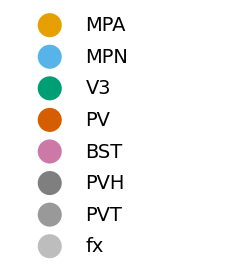

In [19]:
fig, ax = plot_celltype_legend_tight(
    coarse_color,
    ncol=1,              # increase to 2 for a shorter panel
    marker_size=300,
    label_fontsize=14,
    title="",
    filename="./results/figures/domain_legend_tight.pdf"
)
# plt.show()

plt.savefig("./results/figures/domain_color_legend.png", dpi=300, bbox_inches='tight')
